In [90]:
import jax
print(jax.default_backend())
print(jax.devices())


cpu
[CpuDevice(id=0)]


In [91]:
# add project root (parent of figures) to module search path
import sys, os
sys.path.insert(0, os.path.abspath('/home/reilly/ai_scientist_project'))
# import packages
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
import statsmodels.api as sm
from tqdm import tqdm
# import local modules
import utils, loss_functions, seed_programs

# Model Definitions 
## (Uncomment the model you want)

In [ ]:
# BASELINE MODEL
neuron_model_gauss = seed_programs.neuron_model_2_jax
parameter_estimator_gauss = seed_programs.parameter_estimator_2

# SINGLE-PEAK MODEL
neuron_model_gauss_single_peak = seed_programs.neuron_model_1_jax
parameter_estimator_gauss_single_peak = seed_programs.parameter_estimator_1

# AI MODEL
def neuron_model(theta,
                theta_pref_1=0.0,
                baseline=0.0,
                amplitude_1=1.0,
                width_ccw_1=1.0,
                width_cw_1=1.0,
                exponent_1=2.0,
                theta_pref_2=jnp.pi,
                amplitude_2=0.0,
                width_ccw_2=1.0,
                width_cw_2=1.0,
                exponent_2=2.0):

    min_width = 5e-2
    eps = 1e-12
    min_exponent, max_exponent = 0.1, 5.0
    width_ccw_1, width_cw_1 = jnp.clip(width_ccw_1, min_width, None), jnp.clip(width_cw_1, min_width, None)
    width_ccw_2, width_cw_2 = jnp.clip(width_ccw_2, min_width, None), jnp.clip(width_cw_2, min_width, None)
    exponent_1, exponent_2 = jnp.clip(exponent_1, min_exponent, max_exponent), jnp.clip(exponent_2, min_exponent, max_exponent)
    baseline = jnp.clip(baseline, 0.0, None)
    amplitude_1, amplitude_2 = jnp.clip(amplitude_1, 0.0, None), jnp.clip(amplitude_2, 0.0, None)

    def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
        delta = angle_radians - preferred_angle_radians
        return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))
        
    signed_diff_1 = _signed_circ_diff_rad(theta, theta_pref_1) + eps  # Add small epsilon to avoid log(0) issues
    width_1_effective = jnp.where(signed_diff_1 < 0, width_ccw_1, width_cw_1)
    width_1_effective = jnp.maximum(width_1_effective, 1e-6)
    peak1_component = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_1) / width_1_effective) ** exponent_1)

    signed_diff_2 = _signed_circ_diff_rad(theta, theta_pref_2) + eps  # Add small epsilon to avoid log(0) issues
    width_2_effective = jnp.where(signed_diff_2 < 0, width_ccw_2, width_cw_2)
    width_2_effective = jnp.maximum(width_2_effective, 1e-6)
    peak2_component = amplitude_2 * jnp.exp(-0.5 * (jnp.abs(signed_diff_2) / width_2_effective) ** exponent_2)
    return baseline + peak1_component + peak2_component

def parameter_estimator(stimuli, spike_counts):
    """
    Estimates parameters for the neuron_model_v3 based on stimulus angles and observed spike counts.
    This estimator employs statistical principles to identify and characterize tuning curve peaks,
    including baseline, amplitude, asymmetric widths, preferred directions, and exponents for
    two potential peaks.

    Parameters are estimated directly from a smoothed firing rate curve, aiming for a simple
    yet robust initial estimation suitable for generalized Gaussian-like tuning profiles.

    Parameters:
    stimuli (np.ndarray): An array of stimulus angles in radians (0 to 2*pi).
    spike_counts (np.ndarray): An array of spike counts corresponding to each stimulus.

    Returns:
    np.ndarray: An array containing the estimated parameters in the following order:
                [theta_pref_1, baseline, amplitude_1, width_ccw_1, width_cw_1,
                 exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2]
    """
    # --- Configuration Constants ---
    n_bins = 256  # Number of angular bins for tuning curve estimation
    kernel_sigma = 2.5 # Sigma for Gaussian smoothing kernel
    min_peak_amplitude = 0.5 # Min amplitude (spikes/stimulus) above baseline for a peak to be considered valid
    min_model_width = 1e-6 # Minimum allowed width for numerical stability (as per model)
    default_width_value = 1.0 # Default width for non-significant peaks or non-determinable widths
    min_exponent = 0.1 # Minimum allowed exponent value
    max_exponent = 5.0 # Maximum allowed exponent value
    default_exponent_value = 2.0 # Default exponent (Gaussian)
    min_second_peak_ratio = 0.1 # Min amplitude of secondary peak relative to primary
    min_second_peak_separation = np.pi / 4 # Min angular separation between primary and secondary peaks

    # --- 1. Binning and Smoothing ---
    # Convert stimuli to bin indices, handle wrap-around implicitly by modulo in bincount
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # Create Gaussian smoothing kernel
    kernel_radius = int(3 * kernel_sigma)
    x_kernel = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel /= (np.sum(kernel) + 1e-8) # Normalize kernel

    # Pad arrays for circular convolution
    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    # Convolve to get smoothed sum of spikes and counts
    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    # Calculate smoothed tuning curve (avoid division by zero)
    tuning_curve = np.zeros_like(num_conv, dtype=float)
    valid_den_mask = den_conv > 1e-8
    tuning_curve[valid_den_mask] = num_conv[valid_den_mask] / den_conv[valid_den_mask]

    angle_step = 2 * np.pi / n_bins

    # --- 2. Baseline Estimation ---
    # Baseline cannot be negative
    baseline_est = np.maximum(0.0, np.min(tuning_curve))

    # --- Helper function for estimating peak shape parameters ---
    def _get_peak_params_simple(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        if amp < min_amp_thresh:
            return amp, def_w, def_w, def_exp # Return default parameters if amplitude too small

        # Find bins where tuning curve drops below half-max
        target_half_val = bsl + amp / 2.0
        half_ccw_bins, half_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if half_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_half_val:
                half_ccw_bins = k
            if half_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_half_val:
                half_cw_bins = k
            if half_ccw_bins > 0 and half_cw_bins > 0:
                break
        
        # Calculate width (v1-style, implicitly assuming Gaussian form for width parameter base)
        SQRT_2_LOG_2 = np.sqrt(2 * np.log(2)) 
        width_ccw = (half_ccw_bins * ang_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else def_w
        width_cw = (half_cw_bins * ang_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else def_w
        
        # Clip widths to valid range
        width_ccw = np.clip(width_ccw, min_w, np.pi)
        width_cw = np.clip(width_cw, min_w, np.pi)

        # Find bins where tuning curve drops below quarter-max for exponent estimation
        target_qtr_val = bsl + amp / 4.0
        qtr_ccw_bins, qtr_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if qtr_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_qtr_val:
                qtr_ccw_bins = k
            if qtr_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_qtr_val:
                qtr_cw_bins = k
            if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
                break
        
        # Exponent estimation (log(2) / log(dist_qtr / dist_half))
        exponent_estimates = []
        if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins: # Ensure ratio > 1 for valid log
            exponent_estimates.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
        if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
            exponent_estimates.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
        
        # Take mean of valid estimates, else default
        exponent = np.mean(exponent_estimates) if exponent_estimates else def_exp
        exponent = np.clip(exponent, min_exp, max_exp)
        
        return amp, width_ccw, width_cw, exponent

    # --- 3. Peak Identification and Parameter Estimation ---
    # Find all local maxima in the smoothed tuning curve
    local_maxima = []
    for i in range(n_bins):
        prev_val = tuning_curve[(i - 1 + n_bins) % n_bins]
        next_val = tuning_curve[(i + 1) % n_bins]
        if tuning_curve[i] >= prev_val and tuning_curve[i] >= next_val:
            local_maxima.append((tuning_curve[i], i))
    local_maxima.sort(key=lambda x: x[0], reverse=True) # Sort by peak amplitude (descending)

    # Initialize all output parameters with model defaults (if no peak is found)
    theta_pref_1 = 0.0
    amplitude_1 = default_width_value # amplitude for primary peak default to 1 for non-zero contribution if peak is small
    width_ccw_1, width_cw_1, exponent_1 = default_width_value, default_width_value, default_exponent_value
    
    theta_pref_2 = np.pi # Antipodal to default theta_pref_1
    amplitude_2 = 0.0 # Default no second peak
    width_ccw_2, width_cw_2, exponent_2 = default_width_value, default_width_value, default_exponent_value

    # Process Primary Peak
    if local_maxima:
        peak_1_val, peak_1_idx = local_maxima[0]
        # Estimate parameters for the primary (highest) peak
        amplitude_1, width_ccw_1, width_cw_1, exponent_1 = \
            _get_peak_params_simple(peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
                                    min_model_width, default_width_value, min_exponent, max_exponent,
                                    default_exponent_value, min_peak_amplitude)
        theta_pref_1 = peak_1_idx * angle_step
        
        # Process Secondary Peak (if a suitable candidate exists)
        if len(local_maxima) > 1:
            # Iterate through other local maxima to find a suitable secondary peak
            for i in range(1, len(local_maxima)):
                peak_2_val_candidate, peak_2_idx_candidate = local_maxima[i]
                current_amplitude_2_candidate = peak_2_val_candidate - baseline_est
                current_theta_pref_2_candidate = peak_2_idx_candidate * angle_step
                
                # Check amplitude significance relative to primary peak's estimated amplitude
                if current_amplitude_2_candidate < (amplitude_1 * min_second_peak_ratio):
                    continue # Skip if too small compared to the primary peak
                
                # Check angular separation from the *primary* peak
                # np.arctan2(sin(a-b), cos(a-b)) gives circular distance in [-pi, pi]
                peak_sep_rad = np.abs(np.arctan2(np.sin(theta_pref_1 - current_theta_pref_2_candidate),
                                                 np.cos(theta_pref_1 - current_theta_pref_2_candidate)))
                if peak_sep_rad < min_second_peak_separation:
                    continue # Skip if too close to the primary peak

                # Valid secondary peak found, estimate its parameters
                amplitude_2, width_ccw_2, width_cw_2, exponent_2 = \
                    _get_peak_params_simple(peak_2_val_candidate, peak_2_idx_candidate, baseline_est, tuning_curve, n_bins, angle_step,
                                            min_model_width, default_width_value, min_exponent, max_exponent,
                                            default_exponent_value, min_peak_amplitude)
                theta_pref_2 = current_theta_pref_2_candidate
                
                # Break after finding the first suitable secondary peak (highest amplitude among remaining candidates)
                break
    
    # --- Pack and return parameters in the correct order for neuron_model_v3 ---
    return np.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                     exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])
 
param_names = ['theta_pref_1', 'baseline', 'amplitude_1', 'width_ccw_1', 'width_cw_1',
               'exponent_1', 'theta_pref_2', 'amplitude_2', 'width_ccw_2', 'width_cw_2',
               'exponent_2']

# AI MODEL - SINGLE PEAK
def neuron_model_single(theta,
                        theta_pref=0.0,
                        baseline=0.0,
                        amplitude=1.0,
                        width_ccw=1.0,
                        width_cw=1.0,
                        exponent=2.0):
    """
    Single-peak circularly tuned neuron model with asymmetric widths and generalized Gaussian exponent.
    """
    min_width = 5e-2
    eps = 1e-12
    min_exponent, max_exponent = 0.1, 5.0

    # Parameter clipping
    width_ccw, width_cw = jnp.clip(width_ccw, min_width, None), jnp.clip(width_cw, min_width, None)
    exponent = jnp.clip(exponent, min_exponent, max_exponent)
    baseline = jnp.clip(baseline, 0.0, None)
    amplitude = jnp.clip(amplitude, 0.0, None)

    # Circular signed difference
    def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
        delta = angle_radians - preferred_angle_radians
        return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))

    signed_diff = _signed_circ_diff_rad(theta, theta_pref) + eps
    width_effective = jnp.where(signed_diff < 0, width_ccw, width_cw)
    width_effective = jnp.maximum(width_effective, 1e-6)

    # Generalized Gaussian shape
    peak_component = amplitude * jnp.exp(-0.5 * (jnp.abs(signed_diff) / width_effective) ** exponent)
    return baseline + peak_component

def parameter_estimator_single(stimuli, spike_counts):
    """
    Estimate parameters for the single-peak neuron model.

    Parameters:
        stimuli (np.ndarray): Angles (radians, 0 to 2π)
        spike_counts (np.ndarray): Spike counts

    Returns:
        np.ndarray: [theta_pref, baseline, amplitude, width_ccw, width_cw, exponent]
    """
    n_bins = 256
    kernel_sigma = 2.5
    min_model_width = 1e-6
    default_width = 1.0
    min_exponent, max_exponent = 0.1, 5.0
    default_exponent = 2.0
    min_peak_amplitude = 0.5

    # --- Binning ---
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # --- Smoothing (circular Gaussian) ---
    kernel_radius = int(3 * kernel_sigma)
    x = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x / kernel_sigma) ** 2)
    kernel /= np.sum(kernel) + 1e-8

    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    tuning_curve = np.zeros_like(num_conv)
    valid_mask = den_conv > 1e-8
    tuning_curve[valid_mask] = num_conv[valid_mask] / den_conv[valid_mask]

    angle_step = 2 * np.pi / n_bins

    # --- Baseline ---
    baseline = np.maximum(0.0, np.min(tuning_curve))

    # --- Peak detection ---
    peak_idx = np.argmax(tuning_curve)
    peak_val = tuning_curve[peak_idx]
    amplitude = peak_val - baseline

    if amplitude < min_peak_amplitude:
        return np.array([0.0, baseline, amplitude, default_width, default_width, default_exponent])

    # --- Estimate width & exponent ---
    target_half_val = baseline + amplitude / 2
    half_ccw_bins, half_cw_bins = 0, 0
    for k in range(1, n_bins // 2 + 1):
        if half_ccw_bins == 0 and tuning_curve[(peak_idx - k) % n_bins] <= target_half_val:
            half_ccw_bins = k
        if half_cw_bins == 0 and tuning_curve[(peak_idx + k) % n_bins] <= target_half_val:
            half_cw_bins = k
        if half_ccw_bins > 0 and half_cw_bins > 0:
            break

    SQRT_2_LOG_2 = np.sqrt(2 * np.log(2))
    width_ccw = (half_ccw_bins * angle_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else default_width
    width_cw = (half_cw_bins * angle_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else default_width
    width_ccw = np.clip(width_ccw, min_model_width, np.pi)
    width_cw = np.clip(width_cw, min_model_width, np.pi)

    # Exponent from half vs quarter
    target_qtr_val = baseline + amplitude / 4
    qtr_ccw_bins, qtr_cw_bins = 0, 0
    for k in range(1, n_bins // 2 + 1):
        if qtr_ccw_bins == 0 and tuning_curve[(peak_idx - k) % n_bins] <= target_qtr_val:
            qtr_ccw_bins = k
        if qtr_cw_bins == 0 and tuning_curve[(peak_idx + k) % n_bins] <= target_qtr_val:
            qtr_cw_bins = k
        if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
            break

    exponent_est = []
    if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins:
        exponent_est.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
    if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
        exponent_est.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
    exponent = np.mean(exponent_est) if exponent_est else default_exponent
    exponent = np.clip(exponent, min_exponent, max_exponent)

    theta_pref = peak_idx * angle_step

    return np.array([theta_pref, baseline, amplitude, width_ccw, width_cw, exponent])


# Data Loading and Visualization

In [93]:
# 1. Jacob Blocked Data (n_bins=256, signal_fraction_thresh=0.85)
data_dirs = ['/home/reilly/Desktop/jacob data/bz15/data2.npy', '/home/reilly/Desktop/jacob data/bz15/data3.npy', '/home/reilly/Desktop/jacob data/bz15/data5.npy']
metadata_dirs = ['/home/reilly/Desktop/jacob data/bz15/meta2.mat', '/home/reilly/Desktop/jacob data/bz15/meta3.mat', '/home/reilly/Desktop/jacob data/bz15/meta5.mat']

# 2. Jacob Continuous Data (n_bins=180, signal_fraction_thresh=0.85)
# data_dirs = ['/home/reilly/Desktop/BZ016_2025-06-24_1_dspikes.npy']
# metadata_dirs = ['/home/reilly/Desktop/2025-06-24_1_BZ016_Block.mat']

# 3. Ali Lightbeads Data (n_bins = 90)
# data_dir = '/home/reilly/Downloads/grating-data-M01-D1.pickle'

# for all stringer data: n_bins=256, signal_fraction_thresh=0.9
# 4. Stringer Data 1
# data_dir = '/home/reilly/Downloads/8279387/gratings_drifting_GT1_2019_04_12_1.npy'

# 5. Stringer Data 2
# data_dir = '/home/reilly/Downloads/8279387/gratings_drifting_GT2_2019_04_05_1.npy'

# 6. Stringer Data 3
# data_dir = '/home/reilly/Downloads/8279387/gratings_drifting_GT3_2019_04_05_1.npy'
response, angles = utils.load_data(data_dir = [data_dirs, metadata_dirs],
                                   data_type='jacob',
                                   conc_thresh=0.4,
                                   activity_thresh=0.0,
                                   signal_fraction_thresh=0.85,
                                   n_bins=256, min_repeats=6)
signal_fractions = utils.unbiased_signal_fraction(response)[0]

Selected 1907 / 15166 cells with activity > 0.0 and concentration > 0.4.
Selected 586 / 1907 cells with signal fraction > 0.85.


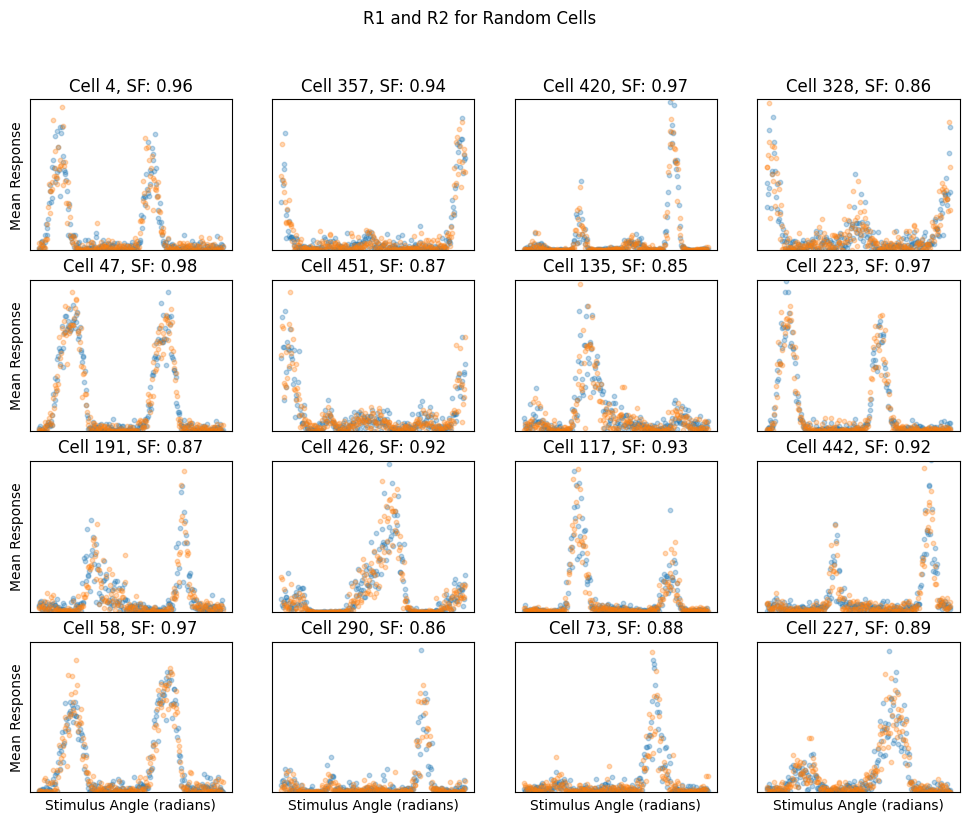

In [94]:
# choose 16 random cells to plot fits for
n_cells = response.shape[1]
random_cells = np.random.choice(n_cells, size=16, replace=False)
plt.figure(figsize=(12, 9))
for i, cell_no in enumerate(random_cells):
    plt.subplot(4, 4, i + 1)
    # plt.scatter(angles, response[:, cell_no].mean(axis=0), s=10, alpha=0.5, label='Data')
    plt.scatter(angles, response[::2, cell_no].mean(axis=0), s=10, alpha=0.3, label='train')
    plt.scatter(angles, response[1::2, cell_no].mean(axis=0), s=10, alpha=0.3, label='test')
    row, col = i // 4, i % 4
    if row == 3:
        plt.xlabel('Stimulus Angle (radians)')
    if col == 0:
        plt.ylabel('Mean Response')
    plt.title(f'Cell {cell_no}, SF: {signal_fractions[cell_no]:.2f}')
    plt.ylim(0, np.percentile(response[:, cell_no], 99) * 1.1)
    plt.xticks([])
    plt.yticks([])
plt.suptitle('R1 and R2 for Random Cells')
plt.show()

# Parameter Fitting

In [95]:
neuron_model_vmap = utils.vmap_over_cells(neuron_model)
neuron_model_gauss_vmap = utils.vmap_over_cells(neuron_model_gauss)
n_repeats, n_cells, n_bins = response.shape

# permute repeats
# response = response[np.random.permutation(n_repeats)]
# n_train_repeats = 3
# n_test_repeats = n_repeats - n_train_repeats
# train_repeats = np.random.choice(n_repeats, size=n_train_repeats, replace=False)
# test_repeats = np.setdiff1d(np.arange(n_repeats), train_repeats)
# define train/test splits
R_train = response[::2].mean(axis=0)
R_test = response[1::2].mean(axis=0)
print(R_train.shape, R_test.shape)

# compute mean responses and double-angle versions
R_mean = response[::2].mean(axis=0)
R_mean_double = (R_mean[:, :n_bins//2] + R_mean[:, n_bins//2:]) / 2.0
angles_double = angles[::2]
response_double = (response[:, :, :n_bins//2] + response[:, :, n_bins//2:]) / 2.0
print(f"Mean data shape: {R_mean.shape}")
print(f"Mean double data shape: {R_mean_double.shape}")
print(f"Angles double shape: {angles_double.shape}")

(586, 256) (586, 256)
Mean data shape: (586, 256)
Mean double data shape: (586, 128)
Angles double shape: (128,)


In [167]:
# get results for orientation tuning (double wrapped data)
# This is only necessary for Jacob and Ali data, since the parameter estimator works well enough on the Stringer data

# results_double = utils.train_simplified(
#     x_data=np.repeat(angles_double[None, :], n_cells, axis=0),
#     y_data=R_mean_double,
#     neuron_model=neuron_model_single,
#     parameter_estimator=parameter_estimator_single,
#     loss_function=loss_functions.quadratic_loss,
#     num_steps=10_000,
#     learning_rate=1e-3,
#     exhaustive_exponents=np.arange(0.5, 3.25, 0.25)
# )
# results_double_gauss = utils.train_simplified(
#     x_data=np.repeat(angles_double[None, :], n_cells, axis=0),
#     y_data=R_mean_double,
#     neuron_model=neuron_model_gauss_single_peak,
#     parameter_estimator=parameter_estimator_gauss_single_peak,
#     loss_function=loss_functions.quadratic_loss,
#     num_steps=10_000,
#     learning_rate=1e-3,
# )
# double wrapped single peak model
params_double = results_double['params']
loss_double = results_double['loss']
# # double wrapped gaussian single peak model
# params_double_gauss = results_double_gauss['params']
# loss_double_gauss = results_double_gauss['loss']

# train
# For Ali and Jacob data, uncomment manual_exponents and potentially adjust learning rate and num_steps
results = utils.train_with_patience_optimization(
    x_data=np.repeat(angles[None, :], n_cells, axis=0),
    y_data=R_train,
    neuron_model=neuron_model,
    parameter_estimator=parameter_estimator,
    loss_function=loss_functions.quadratic_loss,
    learning_rate=1e-3,
    num_steps=12_000,
    val1_fraction=0.2,
    manual_exponents=params_double[:, 5],
)
results_gauss = utils.train_with_patience_optimization(
    x_data=np.repeat(angles[None, :], n_cells, axis=0),
    y_data=R_train,
    neuron_model=neuron_model_gauss,
    parameter_estimator=parameter_estimator_gauss,
    loss_function=loss_functions.quadratic_loss,
    num_steps=12_000,
    learning_rate=1e-3,
    val1_fraction=0.2,
)

# unpack results
params = results['params']
loss = results['loss']
params_dynamic = results['params_dynamic']
# gaussian model
params_gauss = results_gauss['params']
loss_gauss = results_gauss['loss']
params_dynamic_gauss = results_gauss['params_dynamic']

# get cross validted loss
R_test_pred = neuron_model_vmap(angles, params)
R_test_pred_gauss = neuron_model_gauss_vmap(angles, params_gauss)
cv_loss = loss_functions.quadratic_loss(R_test_pred, R_test).mean(axis=-1)
cv_loss_gauss = loss_functions.quadratic_loss(R_test_pred_gauss, R_test).mean(axis=-1)

# calculate R squared between predicted and test responses
R_pred = neuron_model_vmap(angles, params)
R_pred_gauss = neuron_model_gauss_vmap(angles, params_gauss)
ss_res = np.sum((R_test - R_pred) ** 2, axis=-1)
ss_tot = np.sum((R_test - np.mean(R_test, axis=-1, keepdims=True)) ** 2, axis=-1)
r_squared = 1 - ss_res / ss_tot
# same for gaussian model
ss_res_gauss = np.sum((R_test - R_pred_gauss) ** 2, axis=-1)
ss_tot_gauss = np.sum((R_test - np.mean(R_test, axis=-1, keepdims=True)) ** 2, axis=-1)
r_squared_gauss = 1 - ss_res_gauss / ss_tot_gauss

Data split: 205 train, 51 val1, 0 val2

=== Phase A: Train on TRAIN only ===

Step  100 | Train mean: 0.0917 | Val1 mean: 0.1028
Step  200 | Train mean: 0.0857 | Val1 mean: 0.0985
Step  300 | Train mean: 0.0836 | Val1 mean: 0.0973
Step  400 | Train mean: 0.0823 | Val1 mean: 0.0969
Step  500 | Train mean: 0.0814 | Val1 mean: 0.0972
Step  600 | Train mean: 0.0808 | Val1 mean: 0.0973
Step  700 | Train mean: 0.0804 | Val1 mean: 0.0976
Step  800 | Train mean: 0.0801 | Val1 mean: 0.0978
Step  900 | Train mean: 0.0799 | Val1 mean: 0.0981
Step 1000 | Train mean: 0.0797 | Val1 mean: 0.0983
Step 1100 | Train mean: 0.0795 | Val1 mean: 0.0985
Step 1200 | Train mean: 0.0794 | Val1 mean: 0.0988
Step 1300 | Train mean: 0.0793 | Val1 mean: 0.0989
Step 1400 | Train mean: 0.0792 | Val1 mean: 0.0991
Step 1500 | Train mean: 0.0791 | Val1 mean: 0.0994
Step 1600 | Train mean: 0.0790 | Val1 mean: 0.0996
Step 1700 | Train mean: 0.0790 | Val1 mean: 0.0997
Step 1800 | Train mean: 0.0789 | Val1 mean: 0.0999
Step

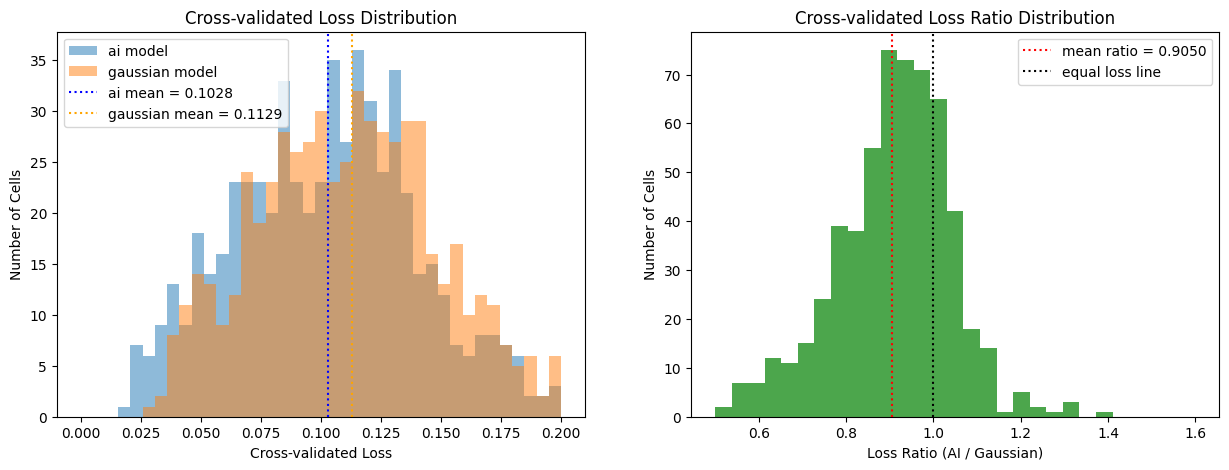

In [168]:
start, end = 0.0, 0.2
n_loss_bins = 40
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.hist(cv_loss, bins=np.linspace(start, end, n_loss_bins), alpha=0.5, label='ai model')
plt.hist(cv_loss_gauss, bins=np.linspace(start, end, n_loss_bins), alpha=0.5, label='gaussian model')
# add vertical line at mean
# plt.axvline(x=np.median(cv_loss), color='blue', linestyle='--', label=f'ai median = {np.median(cv_loss):.4f}')
plt.axvline(x=np.mean(cv_loss), color='blue', linestyle=':', label=f'ai mean = {np.mean(cv_loss):.4f}')
# plt.axvline(x=np.median(cv_loss_gauss), color='orange', linestyle='--', label=f'gaussian median = {np.median(cv_loss_gauss):.4f}')
plt.axvline(x=np.mean(cv_loss_gauss), color='orange', linestyle=':', label=f'gaussian mean = {np.mean(cv_loss_gauss):.4f}')
plt.xlabel('Cross-validated Loss')
plt.ylabel('Number of Cells')
plt.title('Cross-validated Loss Distribution')
plt.legend()
plt.subplot(122)
xmin, xmax = 0.5, 1.6
loss_ratio = cv_loss / cv_loss_gauss
finite_mask = np.isfinite(loss_ratio)
plt.hist(loss_ratio[finite_mask], bins=np.linspace(xmin, xmax, 30), color='green', alpha=0.7)
# plt.axvline(x=np.median(loss_ratio[finite_mask]), color='red', linestyle='--', label=f'median ratio = {np.median(loss_ratio[finite_mask]):.4f}')
plt.axvline(x=np.mean(loss_ratio[finite_mask]), color='red', linestyle=':', label=f'mean ratio = {np.mean(loss_ratio[finite_mask]):.4f}')
plt.axvline(x=1.0, color='black', linestyle=':', label='equal loss line')
plt.xlabel('Loss Ratio (AI / Gaussian)')
plt.ylabel('Number of Cells')
plt.title('Cross-validated Loss Ratio Distribution')
plt.legend()
plt.show()

Plotting fits for cell 191


/tmp/ipykernel_2609880/2803262370.py:158: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


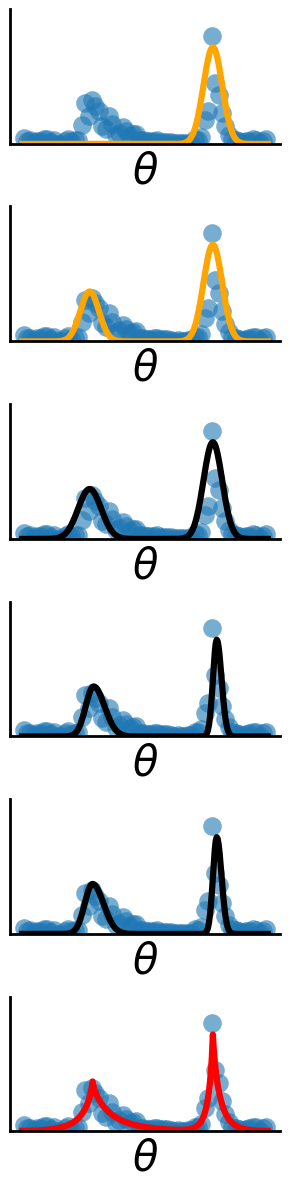

In [586]:
# define intermediate funcs
def neuron_model_3(theta, theta_pref, baseline, amp1, amp2, width1, width2):
    """
    Simplified two-peak neuron model with fixed Gaussian exponent of 2.0.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1,
        width_cw_1=width1,
        exponent_1=2.0,
        theta_pref_2=(theta_pref + np.pi) % (2 * np.pi),
        amplitude_2=amp2,
        width_ccw_2=width2,
        width_cw_2=width2,
        exponent_2=2.0
    )
def neuron_model_4(theta, theta_pref, baseline, amp1, width1_ccw, width1_cw, amp2, width2_ccw, width2_cw):
    """
    Simplified two-peak Gaussian neuron model.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1_ccw,
        width_cw_1=width1_cw,
        theta_pref_2=(theta_pref + np.pi) % (2 * np.pi),
        amplitude_2=amp2,
        width_ccw_2=width2_ccw,
        width_cw_2=width2_cw
    )
def neuron_model_5(theta, theta_pref_1, baseline, amp1, width1_ccw, width1_cw, theta_pref_2, amp2, width2_ccw, width2_cw):
    """
    Simplified two-peak Gaussian neuron model with fixed exponents of 2.0.
    """
    return neuron_model(
        theta,
        theta_pref_1=theta_pref_1,
        baseline=baseline,
        amplitude_1=amp1,
        width_ccw_1=width1_ccw,
        width_cw_1=width1_cw,
        theta_pref_2=theta_pref_2,
        amplitude_2=amp2,
        width_ccw_2=width2_ccw,
        width_cw_2=width2_cw
    )

# cell_no = np.random.randint(n_cells)
cell_no = 191
n_bins_plot = 72
bin_edges = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
scale_factor = 3.0

print(f'Plotting fits for cell {cell_no}')
fig, axes = plt.subplots(6, 1, figsize=(1 * scale_factor, 4 * scale_factor), constrained_layout=True)
axes = axes.ravel()
neuron_models = [seed_programs.neuron_model_1_jax, seed_programs.neuron_model_2_jax, neuron_model_3, neuron_model_4, neuron_model_5, neuron_model]
model_names = ['S1', 'S2', 'A23', 'A27', 'C7', 'D15']
params_single_cell = np.array([params[cell_no]])[0]

# generate predictions for each model
pred = np.zeros((len(neuron_models), angles.shape[0]))
# params for model 1 are theta_pref1, baseline, amp1, width
params_model = params_single_cell[[0, 1, 2, 3]] 
params_model[3] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for single width
pred[0] = neuron_models[0](angles, *params_model)

# params for model 2 are theta_pref1, baseline, amp1, amp2, width
params_model = params_single_cell[[0, 1, 2, 7, 3]]
params_model[4] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for single width
pred[1] = neuron_models[1](angles, *params_model)

# params for model 3 are theta_pref1, baseline, amp1, amp2, width1, width2
params_model = params_single_cell[[0, 1, 2, 7, 3, 8]]
params_model[4] = np.mean([params_single_cell[4], params_single_cell[5]]) * 0.5  # average width_ccw and width_cw for peak 1
params_model[5] = np.mean([params_single_cell[8], params_single_cell[9]]) * 2 # average width_ccw and width_cw for peak 2
pred[2] = neuron_models[2](angles, *params_model)

# params for model 4 are theta_pref1, baseline, amp1, width1_ccw, width1_cw, amp2, width2_ccw, width2_cw
params_model = params_single_cell[[0, 1, 2, 3, 4, 7, 8, 9]]
# scale the widths up a bit
params_model[[3, 4]] *= 1.5  # use original widths scaled up
params_model[[6, 7]] *= 1.5  # use original widths scaled up
# scale left widths up more
params_model[[3, 6]] *= 1.25
# add small rightward shift to theta_pref1
params_model[0] = (params_model[0] + 0.1) % (2 * np.pi)
pred[3] = neuron_models[3](angles, *params_model)

# params for model 5 are theta_pref1, baseline, amp1, width1_ccw, width1_cw, theta_pref2, amp2, width2_ccw, width2_cw
params_model = params_single_cell[[0, 1, 2, 3, 4, 6, 7, 8, 9]]
# scale the widths up a bit
params_model[[3, 4]] *= 1.5  # use original widths scaled up
params_model[[7, 8]] *= 1.5  # use original widths scaled up
# scale left widths up more
params_model[[3, 7]] *= 1.25
# add small rightward shift to theta_pref1
params_model[0] = (params_model[0] + 0.1) % (2 * np.pi)
pred[4] = neuron_models[4](angles, *params_model)

# the final prediction is the AI model
pred[5] = neuron_models[5](angles, *params_single_cell)
colours = ['orange', 'orange', 'k', 'k', 'k', 'red']
for i in range(len(neuron_models)):
    ax = axes[i]

    # Binned means
    angle_masks = [(angles >= bin_edges[j]) & (angles <= bin_edges[j + 1]) for j in range(n_bins_plot)]
    binned_means = np.array([R_train[cell_no][angle_masks[j]].mean() for j in range(n_bins_plot)])

    # Plot test data
    ax.scatter(
        bin_centres, binned_means,
        label='Test Data', 
        color='tab:blue',
        s=60 * scale_factor, alpha=0.6, edgecolor='k', linewidth=0.0 * scale_factor
    )
    # Plot model prediction
    ax.plot(
        angles, pred[i],
        label=rf'{model_names[i]} Model',
        color=colours[i], linewidth=1.5 * scale_factor,
        linestyle='-'
    )

    # Axis labels and formatting
    row = i // 1
    # ax.set_xlabel('Angle (°)' if row == len(neuron_models) - 1 else '', fontsize=12)
    # ax.set_ylabel('Response', fontsize=12)
    ax.set_xticks([])
    # ax.set_xticklabels([f"{int(np.degrees(angle))}" for angle in np.linspace(0, 2 * np.pi, 9)], fontsize=10)
    ax.set_yticks([])
    # ax.tick_params(labelsize=10)
    ax.set_ylim(0, binned_means.max() * 1.25)
    # ax.grid(True, linestyle='--', alpha=0.6)
    # ax.legend(fontsize=10)
    # make the axis outlines thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel(r'$\theta$', fontsize=10 * scale_factor)

    # Title with key cell info
#     ax.set_title(
#         f'Model {model_names[i]} for Cell {cell_no}',
#         fontsize=11
#     )

# plt.suptitle("Neural Response Fits: AI Model vs Gaussian Model vs Test Data", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [169]:
exponent1 = params[:, 5]
exponent2 = params[:, 10]
peaky = np.where((exponent1 < 1.5) | (exponent2 < 1.5))[0]
peaky

array([  3,  17,  19,  40,  48,  52,  53,  54,  56,  59,  66,  67,  70,
        73,  78,  82, 113, 114, 130, 134, 136, 140, 141, 150, 155, 162,
       172, 191, 193, 208, 214, 215, 217, 220, 221, 240, 241, 260, 261,
       262, 272, 274, 285, 287, 290, 292, 293, 297, 299, 300, 301, 302,
       312, 314, 318, 321, 328, 337, 338, 344, 345, 351, 369, 370, 374,
       381, 384, 386, 390, 393, 395, 397, 409, 416, 427, 431, 437, 439,
       440, 445, 448, 452, 461, 471, 473, 491, 493, 495, 497, 498, 504,
       510, 515, 517, 519, 520, 525, 527, 533, 546, 547, 549, 552, 554,
       556, 557, 560, 561, 562, 569, 572, 577])

In [170]:
improved = np.where((r_squared - r_squared_gauss) > 0.05)[0]
print(f'Number of improved cells: {len(improved)}')

Number of improved cells: 67


In [222]:
best_cells = [3
, 52
, 54
, 70
, 130
, 141
, 191
, 220
, 221
, 301
, 321
, 431
, 440
, 510
, 533]

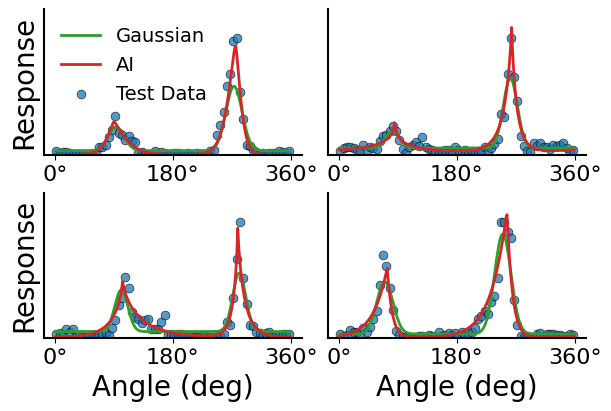

In [520]:
# Example setup
# cells = [187, 624, 639, 741]
# cells = np.random.choice(n_cells, size=4, replace=False)
# cells = np.random.choice(peaky, size=4, replace=False)
# cells = np.random.choice(improved, size=4, replace=False)
cells = [52, 321, 191, 431]
# cells = [70, 221, 440, 431]
# cells = np.random.choice(best_cells, size=4, replace=False)
legend_pos = ['upper left', 'upper left', 'upper left', 'upper right']
n_bins_plot = 72
bin_edges = np.linspace(0, 2 * np.pi, n_bins_plot + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
scale_factor = 2.0
fig, axes = plt.subplots(2, 2, 
                         figsize=(3 * scale_factor, 2 * scale_factor), 
                         constrained_layout=True
                         )
axes = axes.ravel()

for i, cell_no in enumerate(cells):
    ax = axes[i]

    # Predictions
    pred = neuron_model(angles, *params[cell_no])
    pred_gauss = neuron_model_gauss(angles, *params_gauss[cell_no])

    # Binned means
    angle_masks = [(angles >= bin_edges[j]) & (angles <= bin_edges[j + 1]) for j in range(n_bins_plot)]
    binned_means_test = np.array([R_test[cell_no][angle_masks[j]].mean() for j in range(n_bins_plot)])


    # Plot Gaussian model prediction
    ax.plot(
        angles, pred_gauss,
        label='Gaussian',
        color='tab:green', linewidth=2, alpha=1, linestyle='-'
    )

    # Plot AI model prediction
    ax.plot(
        angles, pred,
        label='AI',
        color='tab:red', linewidth=2, alpha=1
    )

    # Plot test data
    ax.scatter(
        bin_centres, binned_means_test,
        label='Test Data', 
        color='tab:blue',
        s=20 * scale_factor, alpha=0.75,
        edgecolors='k', linewidths=0.5
    )


    # Axis labels and formatting
    n_ticks = 3
    row, col = divmod(i, 2)
    ax.set_xlabel('Angle (deg)' if row == 1 else '', fontsize=10 * scale_factor)
    ax.set_ylabel('Response' if col == 0 else '', fontsize=10 * scale_factor)
    ax.set_xticks(np.linspace(0, 2 * np.pi, n_ticks))
    ax.set_xticklabels([f"{int(np.degrees(angle))}°" for angle in np.linspace(0, 2 * np.pi, n_ticks)], fontsize=8 * scale_factor)
    # ax.set_yticks(ax.get_yticks())
    ax.set_yticks([])
    ax.tick_params(labelsize=8 * scale_factor)
    ax.set_ylim(0, binned_means_test.max() * 1.25)
    # remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # make bottom and left spines thicker
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    if row == 0 and col == 0:
        ax.legend(fontsize=7 * scale_factor, loc='upper left', frameon=False)

    # ax.grid(True, linestyle='--', alpha=0.6)
    # ax.legend(fontsize=8 * scale_factor, 
    #         #   loc=legend_pos[i]
    #         )

    # Title with key cell info
    # ax.set_title(
    #     f'Cell {cell_no}',
    # #     f'signal_frac = {signal_fractions[cell_no]:.2f}, '
    # #     f'exp1 = {params[cell_no, 5]:.2f}, exp2 = {params[cell_no, 10]:.2f}',
    #     fontsize=8 * scale_factor
    # )
# plt.suptitle("Neural Response Fits: AI Model vs Gaussian Model vs Test Data", fontsize=14, weight='bold')
# plt.suptitle("Gaussian Model Fits", fontsize=8 * scale_factor)
# plt.tight_layout()
plt.show()

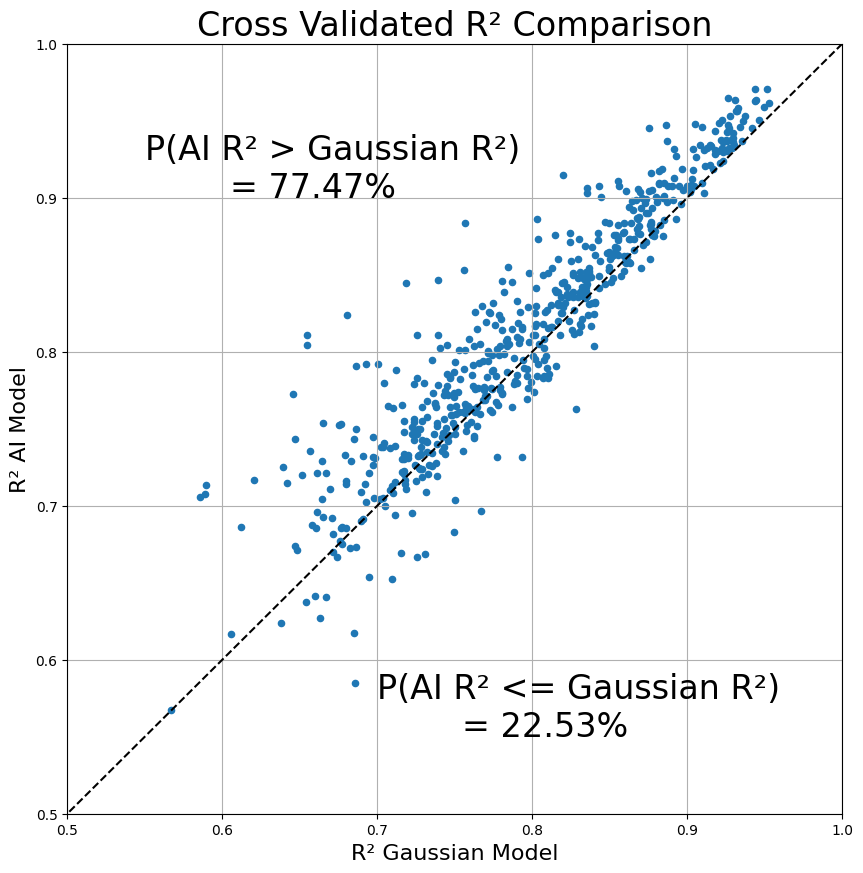

In [173]:
x_min, x_max = 0.5, 1.0
y_min, y_max = 0.5, 1.0
plt.figure(figsize=(10, 10))
plt.scatter(r_squared_gauss, r_squared, alpha=1, color='tab:blue', s=20)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('R² Gaussian Model', fontsize=16)
plt.ylabel('R² AI Model', fontsize=16)
plt.title('Cross Validated R² Comparison', fontsize=24)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True)
# in top left corner, add text showing number of points above y = x line
n_above = np.sum(r_squared > r_squared_gauss)
plt.text(x_min*1.1, y_max*0.9, f'P(AI R² > Gaussian R²) \n        = {n_above / len(r_squared):.2%}', fontsize=24, color='k')
# in bottom right corner, add text showing number of points below y = x line
n_below = np.sum(r_squared <= r_squared_gauss)
plt.text(x_max * 0.7, y_min * 1.1, f'P(AI R² <= Gaussian R²) \n        = {n_below / len(r_squared):.2%}', fontsize=24, color='k')
plt.show()

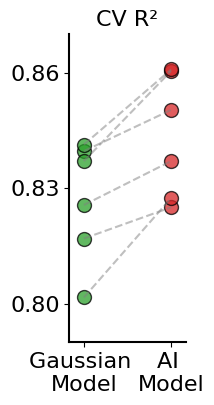

In [593]:
x_min, x_max = 0.75, 2.25
x_gauss = np.ones(6) * x_min
y_gauss = np.array([0.8256, 0.8396, 0.8169, 0.8370, 0.8016, 0.8413])
x_ai = np.ones(6) * x_max
y_ai = np.array([0.8370, 0.8503, 0.8250, 0.8604, 0.8274, 0.8608])
y_gauss_mean = y_gauss.mean()
y_ai_mean = y_ai.mean()
scale_factor = 2.0
plt.figure(figsize=(0.75 * scale_factor, 2 * scale_factor))
plt.scatter(x_gauss, y_gauss, s=50 * scale_factor, alpha=0.75, c='tab:green', edgecolors='k', label='Gauss')
# plt.scatter([1], [y_gauss_mean], s=30 * scale_factor, c='tab:green', marker='^', edgecolors='k', alpha=0.9,
#             label=f'Gauss Mean: {y_gauss_mean:.2f}', zorder=5)
# plt.axhline(y=y_gauss_mean, color='tab:green', linestyle='--', alpha=0.8)
plt.scatter(x_ai, y_ai, s=50 * scale_factor, alpha=0.75, c='tab:red', edgecolors='k', label='AI')
# plt.scatter([2], [y_ai_mean], s=30 * scale_factor, c='tab:red', marker='^', edgecolors='k', alpha=0.9,
#             label=f'AI Mean: {y_ai_mean:.2f}', zorder=5)
# plt.legend(fontsize=8 * scale_factor, loc='upper left', frameon=False)
plt.xticks([x_min, x_max], ['Gaussian \nModel', 'AI \nModel'], fontsize=8 * scale_factor)
# add grey lines joining pairs
for i in range(len(y_gauss)):
    plt.plot([x_gauss[i], x_ai[i]], [y_gauss[i], y_ai[i]], color='gray', linestyle='--', alpha=0.5)
# plt.plot([1, 2], [y_gauss_mean, y_ai_mean], color='black', linestyle='--', alpha=0.8)
# plt.ylabel('Cross-validated R²', 
#            fontsize=8 * scale_factor)
plt.xlim(0.5, 2.5)
plt.ylim(0.79, 0.87)
plt.yticks([0.80, 0.83, 0.86], 
           fontsize=8 * scale_factor)
plt.title('CV R²', fontsize=8 * scale_factor)
# turn off top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# make bottom and left spines thicker
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.savefig('/home/reilly/ai_scientist_project/figures/r2_comparison.svg', format='svg', dpi=300, bbox_inches='tight')

(0.5, 2.5)

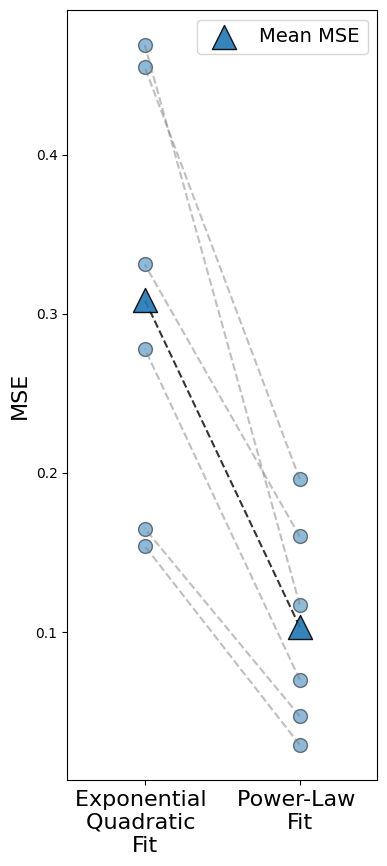

In [102]:
x_loglog = np.ones(6) * 2
y_loglog = np.array([0.117, 0.160, 0.196, 0.070, 0.029, 0.047])
x_loglinear = np.ones(6) * 1
y_loglinear = np.array([0.469, 0.331, 0.455, 0.278, 0.154, 0.165])
y_loglog_mean = y_loglog.mean()
y_loglinear_mean = y_loglinear.mean()
plt.figure(figsize=(4, 10))
plt.scatter(x_loglog, y_loglog, s=100, alpha=0.5, c='tab:blue', edgecolors='k')
plt.scatter([2], [y_loglog_mean], s=300, c='tab:blue', marker='^', edgecolors='k', alpha=0.9,
            label='Mean MSE', zorder=5)
# plt.axhline(y=y_loglog_mean, color='tab:blue', linestyle='--', alpha=0.8)
plt.scatter(x_loglinear, y_loglinear, s=100, alpha=0.5, c='tab:blue', edgecolors='k')
plt.scatter([1], [y_loglinear_mean], s=300, c='tab:blue', marker='^', edgecolors='k', alpha=0.9,zorder=5)
# plt.axhline(y=y_loglinear_mean, color='tab:blue', linestyle='--', alpha=0.8)
plt.xticks([2, 1], ['Power-Law \nFit', 'Exponential \nQuadratic \nFit'], fontsize=16)
plt.legend(fontsize=14, loc='upper right')
# add grey lines joining pairs
for i in range(len(y_loglog)):
    plt.plot([x_loglog[i], x_loglinear[i]], [y_loglog[i], y_loglinear[i]], color='gray', linestyle='--', alpha=0.5)
plt.plot([2, 1], [y_loglog_mean, y_loglinear_mean], color='black', linestyle='--', alpha=0.8)
plt.ylabel('MSE', fontsize=16)
plt.xlim(0.5, 2.5)
# plt.ylim(0, 0.6)


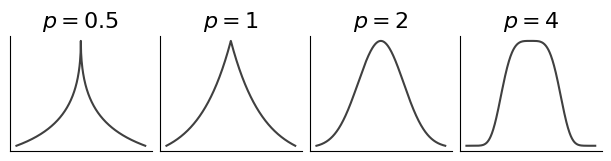

In [587]:
# plot exp(-|x|^p) for p=0.5, 1, 2, 4
x = np.linspace(-2, 2, 501)
scale_factor = 2.0
fig, ax = plt.subplots(1, 4, figsize=(3 * scale_factor, 0.75 * scale_factor), constrained_layout=True)
p_values = [0.5, 1, 2, 4]
for i, p in enumerate(p_values):
    y = np.exp(-np.abs(x) ** p)
    ax[i].plot(x, y, color='k', linewidth=0.75 * scale_factor, alpha=0.75, linestyle='-')
    ax[i].set_title(rf'$p={p}$', fontsize=8 * scale_factor)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    # turn off top and right spines
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    # make bottom and left spines thicker
    # ax[i].spines['bottom'].set_linewidth(1.5)
    # ax[i].spines['left'].set_linewidth(1.5)
# plt.suptitle('Generalized Gaussian Functions', fontsize=20)
plt.show()
